# Week 8 · Day 5 — Training a Real Network + Open Lab

All week you built up to this. Day 2: one neuron by hand. Day 3: backprop from scratch. Day 4: the same network in PyTorch. Today you point that PyTorch at a **real dataset** and do the full, honest job — load, split, build, train, evaluate.

And it's a dataset you already know: the **handwritten digits** you classified with an **SVM back in Week 7**. Today a neural network does the same task. At the end we'll compare — classical ML vs deep learning, head to head, on the same digits.

**The plan:**
1. Load and prepare the digits data (the real workflow: split, scale, tensors).
2. Build an MLP for 10 classes.
3. Train it properly — with batches, watching train *and* test loss.
4. Evaluate — accuracy + confusion matrix (your familiar toolkit).
5. Turn the **practical knobs** and watch what changes.
6. **Open lab** — your own network, your own experiment.

This is the payoff of a hard week. Let's use the tools.

In [1]:
# install if needed (Colab already has torch + sklearn)
# !pip install torch scikit-learn

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)
print("ready")

ready


---
## 1. Load and prepare the data

The **digits** dataset: 1797 tiny 8×8 grayscale images of handwritten digits 0–9. The same set you fed to the SVM in Week 7. Each image is 64 pixels — those 64 numbers are our **inputs** (features), and the digit (0–9) is the **target**.

In [2]:
digits = load_digits()
X = digits.data       # (1797, 64) — 64 pixels per image
y = digits.target     # (1797,)   — the digit 0-9

print("X shape:", X.shape, " (1797 images, 64 pixels each)")
print("y shape:", y.shape, " (one label per image)")
print("labels present:", np.unique(y))

X shape: (1797, 64)  (1797 images, 64 pixels each)
y shape: (1797,)  (one label per image)
labels present: [0 1 2 3 4 5 6 7 8 9]


### Look at the data first (always)
Before training anything, see what you're working with — a habit from every data day this course.

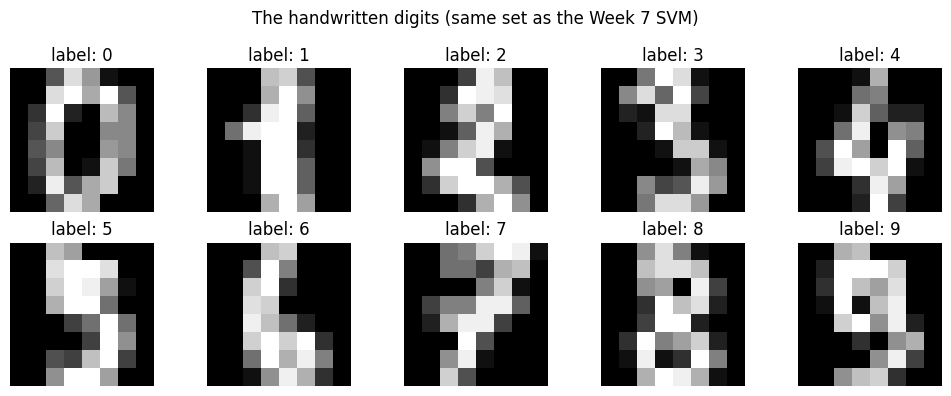

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"label: {y[i]}")
    ax.axis("off")
plt.suptitle("The handwritten digits (same set as the Week 7 SVM)")
plt.tight_layout()
plt.show()

### Split, scale, and convert to tensors
The real workflow has three prep steps — all familiar:

1. **Split** into train and test (so we can measure honestly on data the network never trained on — the same train/test discipline from Week 5).
2. **Scale** the features (neural networks train far better when inputs are on a similar scale — `StandardScaler`, like Week 6).
3. **To tensors** — the one PyTorch-specific step: NumPy arrays become tensors so the network can use them.

In [4]:
# 1. split — 80% train, 20% test (stratified so every digit is represented fairly)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 2. scale — fit on train only, then apply to both (never peek at test)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)   # class labels are long ints
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print("train:", X_train_t.shape, " test:", X_test_t.shape)

train: torch.Size([1437, 64])  test: torch.Size([360, 64])


**One new detail vs XOR.** XOR had one output (0 or 1). Here we have **10 classes** (digits 0–9), so:
- the output layer has **10 neurons** (one score per digit), and
- the labels stay as plain integers (`0`–`9`, type `long`), not one-hot columns.

PyTorch's `CrossEntropyLoss` handles the rest — it's the standard loss for multi-class classification.

---
## 2. Build the network

Same idea as Day 4, just bigger to match a harder problem: **64 inputs → 64 hidden → 32 hidden → 10 outputs.** Two hidden layers this time, and **ReLU** activations (the modern default you met on Day 1 — faster and better than sigmoid for hidden layers).

Notice what's *missing*: no sigmoid on the final layer. For multi-class, we output 10 raw scores and let `CrossEntropyLoss` turn them into probabilities internally. One less thing to write.

In [5]:
class DigitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 64),   # 64 pixels -> 64 hidden
            nn.ReLU(),
            nn.Linear(64, 32),   # 64 -> 32 hidden
            nn.ReLU(),
            nn.Linear(32, 10)    # 32 -> 10 outputs (one per digit)
        )

    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
model = DigitNet()
print(model)

DigitNet(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=10, bias=True)
  )
)


---
## 3. Train — the same four moves, now in batches

The training loop is your old friend: **forward → loss → backward → update.** One practical addition for real data: **batches.**

Instead of showing the network all 1437 training images at once, we show it a **small batch** at a time (say 32 images), update, then the next batch. One full pass over all batches is one **epoch**. Batches make training faster and steadier on real datasets — it's the standard way.

We'll also track **test loss** alongside train loss, so we can *see* overfitting if it appears (the train/test gap from Week 5, back again).

In [6]:
from torch.utils.data import TensorDataset, DataLoader

# DataLoader = PyTorch's batch server: hands us 32 examples at a time, shuffled
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

In [9]:
train_ds[0][0].shape

torch.Size([64])

In [10]:
train_ds[0][1]

tensor(5)

In [11]:
len(train_loader)

45

In [16]:
batch1 = None

for batch in train_loader:
    batch1 = batch
    break

In [23]:
a = batch1[0][0].shape

In [31]:
a[0]

64

In [22]:
len(batch1[1])

32

In [ ]:


loss_fn = nn.CrossEntropyLoss()                          # multi-class loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # Adam: a smarter SGD

train_hist, test_hist = [], []

for epoch in range(50):
    # --- train on batches ---
    model.train()
    for xb, yb in train_loader:          # one batch at a time
        preds = model(xb)                # forward
        loss = loss_fn(preds, yb)        # loss
        optimizer.zero_grad()
        loss.backward()                  # backward
        optimizer.step()                 # update

    # --- record loss on full train & test sets (to watch for overfitting) ---
    model.eval()
    with torch.no_grad():
        train_hist.append(loss_fn(model(X_train_t), y_train_t).item())
        test_hist.append(loss_fn(model(X_test_t), y_test_t).item())

    print(f"Epoch : {epoch+1} --  train loss : {train_hist[-1]}  --  test loss : {test_hist[-1]}")

print(f"final train loss: {train_hist[-1]:.4f}")
print(f"final test  loss: {test_hist[-1]:.4f}")

Epoch : 1 --  train loss : 0.15651348233222961  --  test loss : 0.2826247215270996
Epoch : 2 --  train loss : 0.08894229680299759  --  test loss : 0.17026641964912415
Epoch : 3 --  train loss : 0.02417208068072796  --  test loss : 0.09961625188589096
Epoch : 4 --  train loss : 0.023681888356804848  --  test loss : 0.08944296091794968
Epoch : 5 --  train loss : 0.01584290899336338  --  test loss : 0.11486843973398209
Epoch : 6 --  train loss : 0.023438068106770515  --  test loss : 0.15268170833587646
Epoch : 7 --  train loss : 0.00726325111463666  --  test loss : 0.14576074481010437
Epoch : 8 --  train loss : 0.0008748389664106071  --  test loss : 0.12644512951374054
Epoch : 9 --  train loss : 0.0005677586887031794  --  test loss : 0.12456350028514862
Epoch : 10 --  train loss : 0.00044245165190659463  --  test loss : 0.12348692119121552
Epoch : 11 --  train loss : 0.00036469436599873006  --  test loss : 0.12382195889949799
Epoch : 12 --  train loss : 0.00031254097120836377  --  test lo

Two things are new here, both worth a sentence:
- **`Adam`** instead of `SGD` — a smarter optimizer that adapts the step size automatically. It's the go-to default; think of it as SGD that tunes its own learning rate.
- **`model.train()` / `model.eval()`** — flags that tell the network which mode it's in. Harmless for now; they matter once you add things like dropout. Get in the habit.

Everything else is the four moves you've known since Week 5.

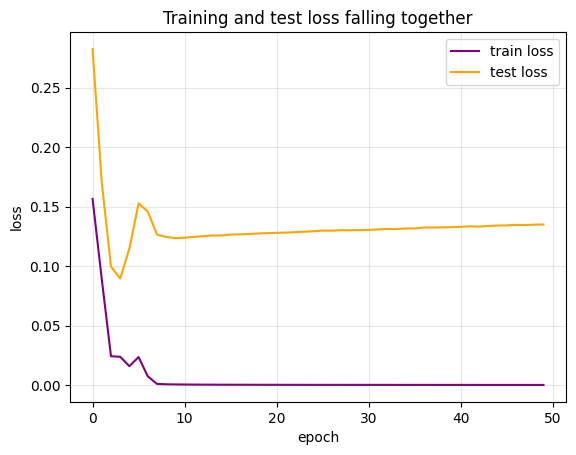

In [33]:
plt.plot(train_hist, label="train loss", color="purple")
plt.plot(test_hist, label="test loss", color="orange")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("Training and test loss falling together")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

Watch the two lines. As long as **test loss falls with train loss**, the network is genuinely learning. If test loss ever starts *rising* while train loss keeps falling — that's **overfitting** (memorizing the training set). We'll provoke that on purpose in the knobs section.

---
## 4. Evaluate — the familiar toolkit

Accuracy on the held-out test set, then a **confusion matrix** — exactly the tools you used for the SVM. This is how we judge any classifier.

In [34]:
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    predictions = logits.argmax(dim=1)   # the digit with the highest score

accuracy = (predictions == y_test_t).float().mean().item()
print(f"test accuracy: {accuracy:.2%}")

test accuracy: 97.50%


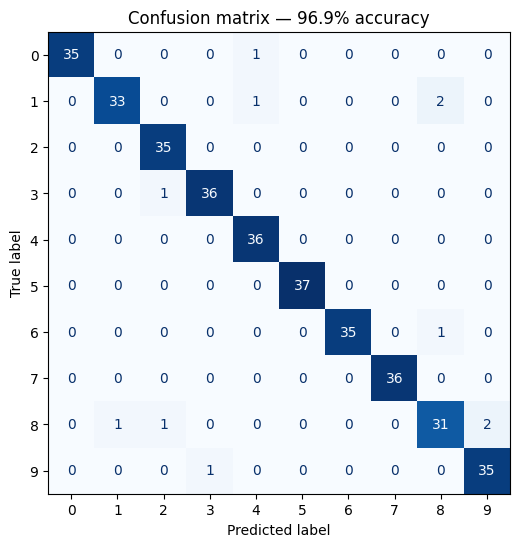

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_t, predictions)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion matrix — {accuracy:.1%} accuracy")
plt.show()

The strong diagonal means most digits are classified correctly. Off-diagonal cells show the mistakes — often the digits that look alike to a human too (like 3↔8 or 4↔9). Same read as any confusion matrix you've made.

### Look at the mistakes
Seeing *which* images fooled the network is one of the most useful debugging habits there is.

the network got 11 of 360 test images wrong


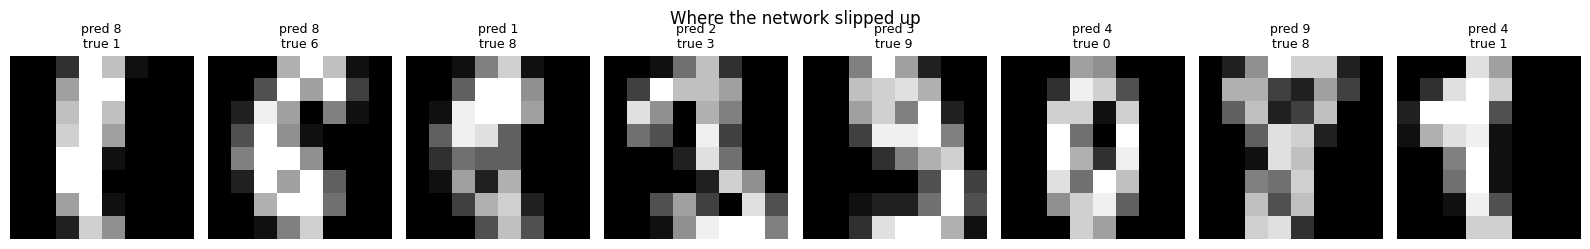

In [10]:
wrong = np.where(predictions.numpy() != y_test_t.numpy())[0]
print(f"the network got {len(wrong)} of {len(y_test_t)} test images wrong")

if len(wrong) > 0:
    show = wrong[:8]
    fig, axes = plt.subplots(1, len(show), figsize=(2*len(show), 2.5))
    axes = np.atleast_1d(axes)
    # recover the original 8x8 image from the scaled row
    X_test_orig = scaler.inverse_transform(X_test)
    for ax, idx in zip(axes, show):
        ax.imshow(X_test_orig[idx].reshape(8, 8), cmap="gray")
        ax.set_title(f"pred {predictions[idx].item()}\ntrue {y_test_t[idx].item()}", fontsize=9)
        ax.axis("off")
    plt.suptitle("Where the network slipped up")
    plt.tight_layout()
    plt.show()

### Neural network vs SVM — the bridge

In Week 7 the SVM classified these same digits. Now a neural network does too. Run the SVM here on the identical split and compare honestly.

In [11]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", gamma=0.001)
svm.fit(X_train, y_train)
svm_acc = svm.score(X_test, y_test)

print(f"SVM  accuracy:  {svm_acc:.2%}")
print(f"MLP  accuracy:  {accuracy:.2%}")
print("\nBoth do very well on this small, clean dataset.")
print("The neural network's real advantage shows up on bigger, messier data —")
print("and on images specifically, once we reach CNNs.")

SVM  accuracy:  95.00%
MLP  accuracy:  96.94%

Both do very well on this small, clean dataset.
The neural network's real advantage shows up on bigger, messier data —
and on images specifically, once we reach CNNs.


An honest lesson: on a **small, clean** dataset like this, a well-tuned classical model (SVM) is right there with the neural network — sometimes ahead. Deep learning isn't automatically better. Its edge appears with **scale** and with **raw, unstructured data** (images, text, audio) — which is exactly where the rest of the course is heading (CNNs next week).

---
## 5. The practical knobs

These are the settings that decide whether training works. We'll wrap training in a small function so you can turn one knob at a time and *see* the effect — the most useful skill for real deep learning work.

Run each experiment and read the result. There's no memorizing here — you're building intuition by watching.

In [12]:
def train_and_score(hidden=(64, 32), lr=0.01, epochs=50, seed=42):
    """Build + train an MLP with the given knobs; return final train/test accuracy."""
    torch.manual_seed(seed)
    layers, prev = [], 64
    for h in hidden:
        layers += [nn.Linear(prev, h), nn.ReLU()]
        prev = h
    layers += [nn.Linear(prev, 10)]
    net = nn.Sequential(*layers)

    opt = torch.optim.Adam(net.parameters(), lr=lr)
    lossf = nn.CrossEntropyLoss()
    loader = DataLoader(train_ds, batch_size=32, shuffle=True)

    for _ in range(epochs):
        net.train()
        for xb, yb in loader:
            loss = lossf(net(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()

    net.eval()
    with torch.no_grad():
        tr = (net(X_train_t).argmax(1) == y_train_t).float().mean().item()
        te = (net(X_test_t).argmax(1) == y_test_t).float().mean().item()
    return tr, te

### Knob 1 — learning rate
The single most important setting. Too high and training diverges; too low and it crawls. Same lesson as gradient descent in Week 5 — now it really bites.

In [13]:
print("learning rate   train acc   test acc")
for lr in [0.0001, 0.001, 0.01, 0.1, 1.0]:
    tr, te = train_and_score(lr=lr, epochs=30)
    print(f"   {lr:<10}    {tr:.2%}      {te:.2%}")
print("\nToo small (0.0001) → underfits, hasn't learned enough yet.")
print("Just right (~0.01) → strong test accuracy.")
print("Too big (1.0) → unstable, accuracy collapses.")

learning rate   train acc   test acc
   0.0001        94.50%      93.06%
   0.001         100.00%      96.94%
   0.01          100.00%      97.50%
   0.1           15.59%      18.89%
   1.0           10.09%      10.00%

Too small (0.0001) → underfits, hasn't learned enough yet.
Just right (~0.01) → strong test accuracy.
Too big (1.0) → unstable, accuracy collapses.


### Knob 2 — network size
More neurons and layers = more power to fit — but also more capacity to **overfit** (memorize the training set). Watch the gap between train and test accuracy grow as the network gets bigger.

In [14]:
print("network size          train acc   test acc   gap")
for hidden in [(16,), (64, 32), (256, 128, 64)]:
    tr, te = train_and_score(hidden=hidden, epochs=40)
    print(f"   {str(hidden):<18}  {tr:.2%}      {te:.2%}    {tr-te:+.2%}")
print("\nEvery size fits the training set near-perfectly (train acc ~100%).")
print("The train-test GAP is the tell: the bigger the gap, the more the")
print("network memorized rather than learned. On this small clean dataset")
print("the gap stays modest — but on messier data it grows fast with size.")

network size          train acc   test acc   gap
   (16,)               99.93%      97.50%    +2.43%
   (64, 32)            100.00%      97.22%    +2.78%
   (256, 128, 64)      100.00%      96.67%    +3.33%

Every size fits the training set near-perfectly (train acc ~100%).
The train-test GAP is the tell: the bigger the gap, the more the
network memorized rather than learned. On this small clean dataset
the gap stays modest — but on messier data it grows fast with size.


### Knob 3 — epochs
Too few and the network hasn't finished learning (**underfitting**). Past a point, extra epochs stop helping — the network has learned what it can from this data. On bigger, messier datasets, training too long is where **overfitting** creeps in.

In [15]:
print("epochs   train acc   test acc")
for ep in [5, 20, 50, 150]:
    tr, te = train_and_score(epochs=ep)
    print(f"  {ep:<5}   {tr:.2%}      {te:.2%}")
print("\nFew epochs (5) → still underfitting a little.")
print("Enough (~20-50) → the network has essentially converged.")
print("More (150) → barely moves: diminishing returns. The data has no more to give.")

epochs   train acc   test acc
  5       99.72%      96.11%
  20      98.89%      95.28%
  50      100.00%      96.94%
  150     100.00%      97.78%

Few epochs (5) → still underfitting a little.
Enough (~20-50) → the network has essentially converged.
More (150) → barely moves: diminishing returns. The data has no more to give.


**The three knobs, in one breath:** learning rate controls *how fast* it learns, network size controls *how much* it can learn, epochs control *how long* it learns. Push learning rate too far and training breaks; push size or epochs too far on messy data and it overfits. Good deep learning is largely the craft of balancing these — and you now know how to test them by watching the train-test gap.

---
## 6. Open Lab (assessed) 🧪

Your turn. Build and train your **own** neural network, then run **one** experiment and report what you saw. This is graded on the process, not on hitting a magic accuracy number.

### Pick a dataset (all load instantly from sklearn)
- **`load_digits`** — the digits above (start here if unsure; you can go deeper on the knobs).
- **`load_wine`** — 13 features, 3 classes of wine. A tabular problem.
- **`load_breast_cancer`** — 30 features, 2 classes (malignant/benign). A real, meaningful binary task.

### Requirements (the checklist)
1. **Load and prepare** — split into train/test and scale the features.
2. **Build an MLP** in PyTorch (adjust the input size to your dataset's features and the output size to its number of classes).
3. **Train it** — write the loop, watch the loss fall, plot it.
4. **Evaluate** on the test set — accuracy **and** a confusion matrix.
5. **Experiment with one knob** — learning rate, network size, or epochs. Try at least three values and report what changed.
6. **Write 3–4 sentences**: what you built, what your experiment showed, and one thing that surprised you.

💡 *The classic beginner bug is a **shape mismatch** — the input layer must match the number of features, the output layer must match the number of classes. When PyTorch complains about shapes, that's almost always it. Ask for help; it's a normal part of the job.*

Starter cells below — fill in the blanks.

In [16]:
# --- STARTER: load your dataset (uncomment one) ---
from sklearn.datasets import load_wine, load_breast_cancer, load_digits

data = load_wine()            # <- or load_breast_cancer() or load_digits()
X = data.data
y = data.target

n_features = X.shape[1]
n_classes = len(np.unique(y))
print(f"features: {n_features}   classes: {n_classes}")

# TODO: split into train/test (stratify=y), scale with StandardScaler,
#       and convert all four arrays to tensors (X float32, y long).


features: 13   classes: 3


In [ ]:
# --- STARTER: build your network ---
# TODO: fill in the input size (n_features) and output size (n_classes).
#       Keep a hidden layer or two with ReLU in between.
#
# my_model = nn.Sequential(
#     nn.Linear(n_features, 32),
#     nn.ReLU(),
#     nn.Linear(32, n_classes)
# )


In [ ]:
# --- STARTER: train (the four moves), then evaluate ---
# TODO: set up CrossEntropyLoss + an Adam optimizer, write the training loop,
#       record the loss, plot it, then report test accuracy + a confusion matrix.
#       Finally, change ONE knob and rerun to see what happens.


> ✍️ **My write-up (3–4 sentences):**
>
> *(What did you build? What did your knob experiment show? What surprised you?)*

---
## Summary — and the end of Week 8

- The **real workflow**: load → look → split → scale → to tensors → build → train → evaluate. The same shape for every supervised problem.
- Multi-class needs a **10-neuron output** and **`CrossEntropyLoss`** — no final sigmoid, labels stay as integers.
- **Batches** (via `DataLoader`) and **Adam** are the standard practical tools; the training loop is still your four moves.
- Judge with the **familiar toolkit**: test accuracy + confusion matrix + looking at the mistakes.
- The **knobs** — learning rate, network size, epochs — decide whether training works, and every one can cause overfitting if pushed too far. You now know how to test them.
- **NN vs SVM:** on small clean data they're neck and neck. Deep learning pulls ahead with scale and raw data — where we're headed next.

**You built the engine of deep learning from a single neuron, by hand, and then drove a real network with it.** That's the whole of Week 8.

**Next week:** **CNNs** — networks built for images, where the neural network finally leaves the SVM behind.

*GitHub push:* `week-08/neural-network-project.ipynb`